In [2]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:
DATASET_PATH = "dataset"
categories = ["covid", "normal"]
images = []
labels = []
for label, category in enumerate(categories):
    path = os.path.join(DATASET_PATH, category)
    print("Reading:", path)
    for file in os.listdir(path):
        file_path = os.path.join(path, file)
        img = cv2.imread(file_path)
        if img is None:     
            print("Bad image:", file)
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img, (150, 150))
        images.append(img)
        labels.append(label)
images = np.array(images)
labels = np.array(labels)
print("\nDataset Loaded Successfully!")
print("Total Images:", len(images))
print("Image Tensor Shape:", images.shape)
X = images.reshape(len(images), -1)   
y = labels
print("Flattened Feature Shape:", X.shape)

Reading: dataset\covid
Reading: dataset\normal

Dataset Loaded Successfully!
Total Images: 94
Image Tensor Shape: (94, 150, 150)
Flattened Feature Shape: (94, 22500)


In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)
print("\nTraining Samples:", len(X_train))
print("Validation Samples:", len(X_val))
print("Test Samples:", len(X_test))
print()


Training Samples: 65
Validation Samples: 14
Test Samples: 15



In [5]:
baseline_model = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation='relu',
    max_iter=20,
    random_state=42
)
print("Training Baseline Model...")
baseline_model.fit(X_train, y_train)
baseline_val_pred = baseline_model.predict(X_val)
baseline_acc = accuracy_score(y_val, baseline_val_pred)
print("Baseline Validation Accuracy:", baseline_acc)
print()

Training Baseline Model...
Baseline Validation Accuracy: 0.7142857142857143



c:\Users\abdul\Downloads\covid\covid_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [6]:
tuned_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    max_iter=50,
    alpha=0.0001,
    random_state=42
)
print("Training Tuned Model...")
tuned_model.fit(X_train, y_train)
val_pred = tuned_model.predict(X_val)
val_acc = accuracy_score(y_val, val_pred)
print("Improved Model Validation Accuracy:", val_acc)
print()

Training Tuned Model...
Improved Model Validation Accuracy: 1.0



FINAL TEST ACCURACY: 0.9333333333333333

Classification Report:

              precision    recall  f1-score   support

       covid       0.92      1.00      0.96        11
      normal       1.00      0.75      0.86         4

    accuracy                           0.93        15
   macro avg       0.96      0.88      0.91        15
weighted avg       0.94      0.93      0.93        15



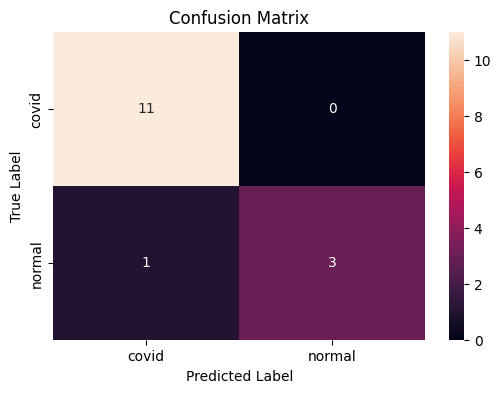

In [7]:
test_pred = tuned_model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)
print("FINAL TEST ACCURACY:", test_acc)
print("\nClassification Report:\n")
print(classification_report(y_test, test_pred, target_names=categories))
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, xticklabels=categories, yticklabels=categories)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

In [8]:

import joblib
mlp = MLPClassifier(hidden_layer_sizes=(256,128), max_iter=50, random_state=42)
mlp.fit(X_train, y_train)
joblib.dump(mlp, "mlp_covid_model.pkl")

['mlp_covid_model.pkl']